In [ ]:
"""
Toxic Comment Classification Challenge
Author: Jeannette Helsby
University of Liverpool - Machine Learning Assessment 2026
Dataset: https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge

Note: Place train.csv and test.csv in:
../data/jigsaw-toxic-comment-classification-challenge/

"""

# Toxic Comment Classification

## Step 1 - Data Analysis

### 1.1 Load Data

In [2]:
# ==============================================
# STEP 1: DATA ANALYSIS
# Loads dataset, checks class distribution,
# token counts and most common words per class
# ==============================================

# Extract dataset files if not already extracted

In [ ]:
!pip install matplotlib
!pip install nltk
!pip install gensim

In [152]:
# Extract dataset files if not already extracted
import zipfile
import os
import pandas as pd
import string
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

path = '../data'
for f in os.listdir(path):
    if f.endswith('.zip'):
        with zipfile.ZipFile(os.path.join(path, f), 'r') as z:
            z.extractall(path)
            print(f'Extracted: {f}')
# Load training dataset
toxic_df = pd.read_csv('../data/jigsaw-toxic-comment-classification-challenge/train.csv')

Extracted: jigsaw-toxic-comment-classification-challenge.zip
Extracted: test.csv.zip
Extracted: test_labels.csv.zip
Extracted: train.csv.zip
Extracted: sample_submission.csv.zip


### 1.2 Class Distribution & Imbalance

In [153]:
toxic_df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

### 1.3 Token Counts Per Class

In [154]:
class_counts = toxic_df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].sum()
# Visualize the class data
class_counts.plot

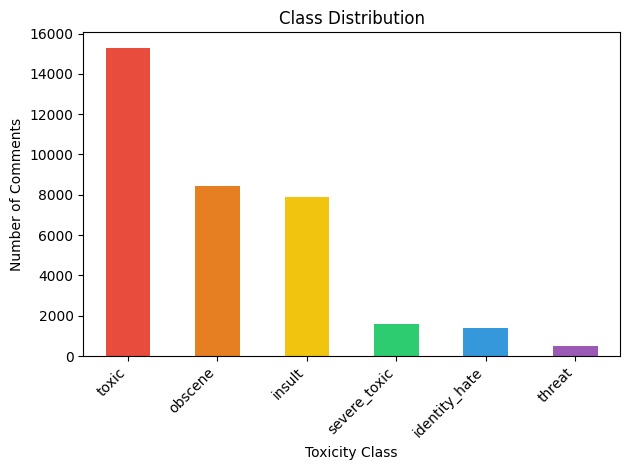

In [155]:
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']
class_counts.sort_values(ascending=False).plot(kind='bar', color=colors)
plt.title('Class Distribution')
plt.ylabel('Number of Comments')
plt.xlabel('Toxicity Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [159]:
# Calculate token count (number of words) for each comment
toxic_df['token_count'] = toxic_df['comment_text'].apply(lambda x: len(x.split()))

In [160]:
# Calculate average token count per toxicity class
for class_name in ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']:
    avg = toxic_df[toxic_df[class_name] == 1]['token_count'].mean()
    print(f'{class_name}: {avg:.1f} tokens')

toxic: 51.3 tokens
severe_toxic: 75.6 tokens
obscene: 49.6 tokens
threat: 55.2 tokens
insult: 48.3 tokens
identity_hate: 52.0 tokens


### 1.4 Most Common Words Per Class

In [162]:
# Install and import NLTK for stopword filtering
nltk.download('stopwords', quiet=True)

# Load English stopwords to filter common words during text analysis
stop_words = set(stopwords.words('english'))

#### Toxic Class

In [172]:
# Extract and clean toxic comments - lowercase, remove punctuation and stopwords
toxic_text=' '.join(toxic_df[toxic_df['toxic'] == 1]['comment_text'])
toxic_words = toxic_text.lower().split()
toxic_words_clean = [word.translate(str.maketrans('', '', string.punctuation)) for word in toxic_words if word not in stop_words and word != '']
toxic_words_clean = [word for word in toxic_words_clean if word != '']

# Count word frequencies for toxic class and display top 20 most common words
toxic_word_counts = Counter(toxic_words_clean)

# Extract top 20 words and their frequencies for plotting
words = [pair[0] for pair in toxic_word_counts.most_common(20)]
counts = [pair[1] for pair in toxic_word_counts.most_common(20)]

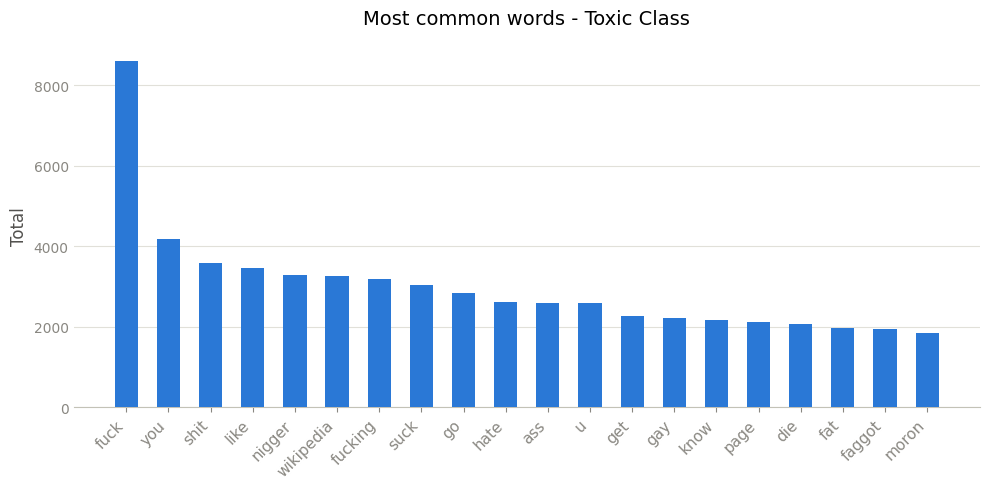

In [173]:
# Plot top 20 most common words for toxic class
title = 'Most common words - Toxic Class'

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(words, counts, color='#2a78d6', width=0.55, zorder=3)

for bar in bars:
    bar.set_linewidth(0)

ax.set_title(title, fontsize=14, fontweight='500', pad=14)

ax.set_ylabel('Total', fontsize=12, color='#52514e')

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')

ax.tick_params(axis='x', colors='#898781', rotation=45)
ax.tick_params(axis='y', colors='#898781', length=0)
plt.setp(ax.get_xticklabels(), ha='right', fontsize=11)

plt.tight_layout()
plt.show()

#### Severe Toxic class

In [169]:
# Extract and clean comments - lowercase, remove punctuation and stopwords
stoxic_text=' '.join(toxic_df[toxic_df['severe_toxic'] == 1]['comment_text'])
stoxic_words = stoxic_text.lower().split()
stoxic_words_clean = [word.translate(str.maketrans('', '', string.punctuation)) for word in stoxic_words if word not in stop_words and word != '']
stoxic_words_clean = [word for word in stoxic_words_clean if word != '']
st_word_counts = Counter(stoxic_words_clean)
# Extract top 20 words and their frequencies for plotting
swords = [pair[0] for pair in st_word_counts.most_common(20)]
scounts = [pair[1] for pair in st_word_counts.most_common(20)]

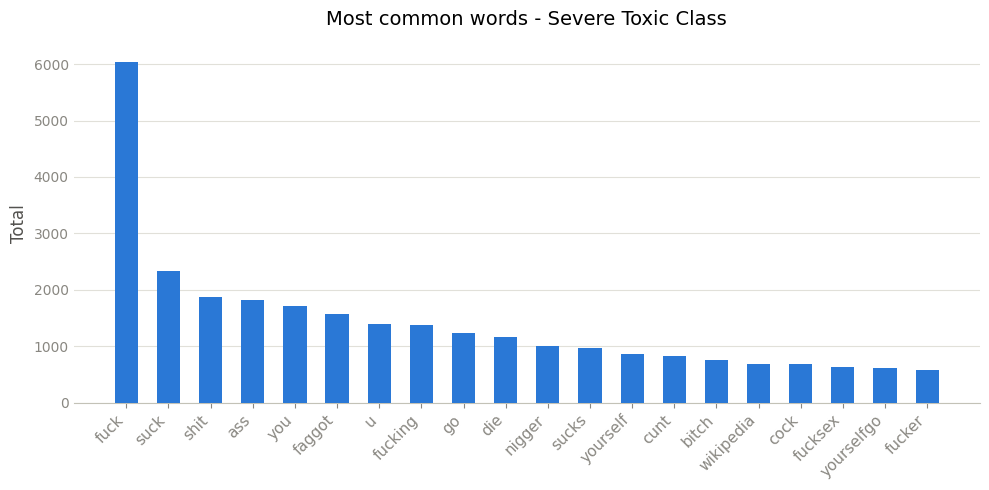

In [170]:
# Plot top 20 most common words for severe toxic class
title = 'Most common words - Severe Toxic Class'
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(swords, scounts, color='#2a78d6', width=0.55, zorder=3)

for bar in bars:
    bar.set_linewidth(0)

ax.set_title(title, fontsize=14, fontweight='500', pad=14)

ax.set_ylabel('Total', fontsize=12, color='#52514e')

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')

ax.tick_params(axis='x', colors='#898781', rotation=45)
ax.tick_params(axis='y', colors='#898781', length=0)
plt.setp(ax.get_xticklabels(), ha='right', fontsize=11)

plt.tight_layout()
plt.show()

#### Obscene Class

In [85]:
obscene_text=' '.join(toxic_df[toxic_df['obscene'] == 1]['comment_text'])
obscene_words = obscene_text.lower().split()
obscene_words_clean = [word.translate(str.maketrans('', '', string.punctuation)) for word in obscene_words if word not in stop_words]
obscene_words_clean = [word for word in obscene_words_clean if word != '']
obscene_word_counts = Counter(obscene_words_clean)
owords = [pair[0] for pair in st_word_counts.most_common(20)]
ocounts = [pair[1] for pair in st_word_counts.most_common(20)]

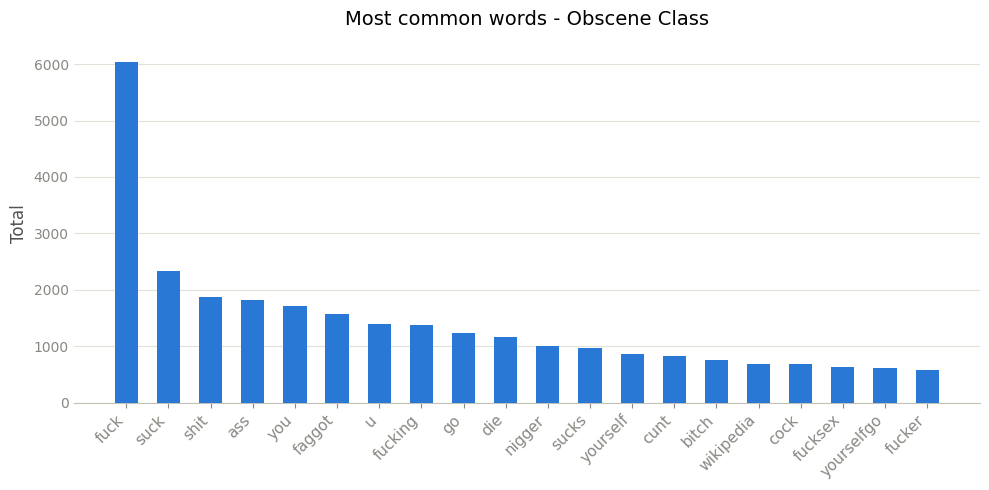

In [89]:
# Plot top 20 most common words for obscene class
title = 'Most common words - Obscene Class'
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(owords, ocounts, color='#2a78d6', width=0.55, zorder=3)

for bar in bars:
    bar.set_linewidth(0)

ax.set_title(title, fontsize=14, fontweight='500', pad=14)

ax.set_ylabel('Total', fontsize=12, color='#52514e')

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')

ax.tick_params(axis='x', colors='#898781', rotation=45)
ax.tick_params(axis='y', colors='#898781', length=0)
plt.setp(ax.get_xticklabels(), ha='right', fontsize=11)

plt.tight_layout()
plt.show()

#### Threat Class

In [174]:
thread_text = ' '.join(toxic_df[toxic_df['threat'] == 1]['comment_text'])
thread_words = thread_text .lower().split()
thread_words_clean = [word.translate(str.maketrans('', '', string.punctuation)) for word in thread_words if word not in stop_words]
thread_words_clean = [word for word in thread_words_clean if word != '']
thread_words_count = Counter(thread_words_clean)
twords = [pair[0] for pair in thread_words_count.most_common(20)]
tcounts = [pair[1] for pair in thread_words_count.most_common(20)]

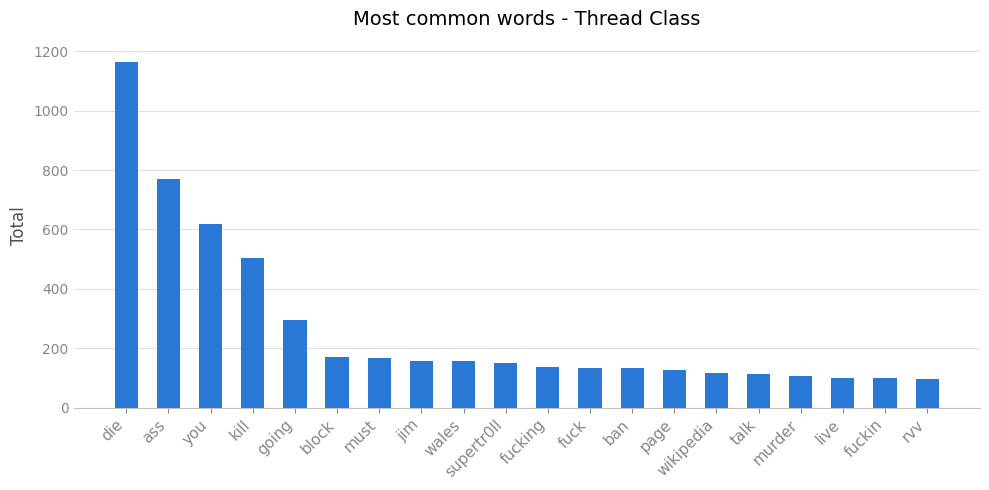

In [175]:
# Plot top 20 most common words for  thread class
title = 'Most common words - Thread Class'
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(twords, tcounts, color='#2a78d6', width=0.55, zorder=3)

for bar in bars:
    bar.set_linewidth(0)

ax.set_title(title, fontsize=14, fontweight='500', pad=14)

ax.set_ylabel('Total', fontsize=12, color='#52514e')

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')

ax.tick_params(axis='x', colors='#898781', rotation=45)
ax.tick_params(axis='y', colors='#898781', length=0)
plt.setp(ax.get_xticklabels(), ha='right', fontsize=11)

plt.tight_layout()
plt.show()

#### Insult Class

In [176]:
# 
insult_text= ' '.join(toxic_df[toxic_df['insult']== 1]['comment_text'])
insult_words=insult_text.lower().split()
insult_words_clean = [word.translate(str.maketrans('', '', string.punctuation)) for word in insult_words if word not in stop_words ]
insult_words_clean = [word for word in insult_words_clean if word != '']
insult_words_count = Counter(insult_words_clean)
iwords = [pair[0] for pair in insult_words_count.most_common(20)]
icounts = [pair[1] for pair in insult_words_count.most_common(20)]

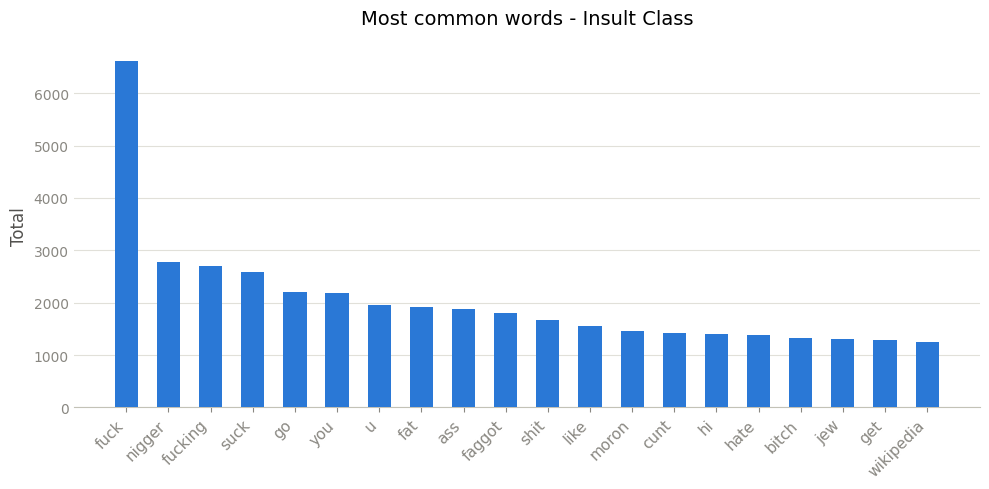

In [177]:
# Plot top 20 most common words for  Insult  class
title = 'Most common words - Insult Class'
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(iwords, icounts, color='#2a78d6', width=0.55, zorder=3)

for bar in bars:
    bar.set_linewidth(0)

ax.set_title(title, fontsize=14, fontweight='500', pad=14)

ax.set_ylabel('Total', fontsize=12, color='#52514e')

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')

ax.tick_params(axis='x', colors='#898781', rotation=45)
ax.tick_params(axis='y', colors='#898781', length=0)
plt.setp(ax.get_xticklabels(), ha='right', fontsize=11)

plt.tight_layout()
plt.show()


#### Identity_Hate Class

In [178]:

hate_text= ' '.join(toxic_df[toxic_df['identity_hate']==1]['comment_text'])
hate_words= hate_text.lower().split()

#Clean
hate_words_clean= [ word.translate(str.maketrans('', '', string.punctuation))   for word in hate_words if word not in stop_words ]
hate_words_clean = [ word for word in hate_words_clean if word != '' ]
hate_words_count = Counter(hate_words_clean)
hwords = [ pair[0] for pair in hate_words_count.most_common(20)]
hcounts = [ pair[1] for pair in hate_words_count.most_common(20)]

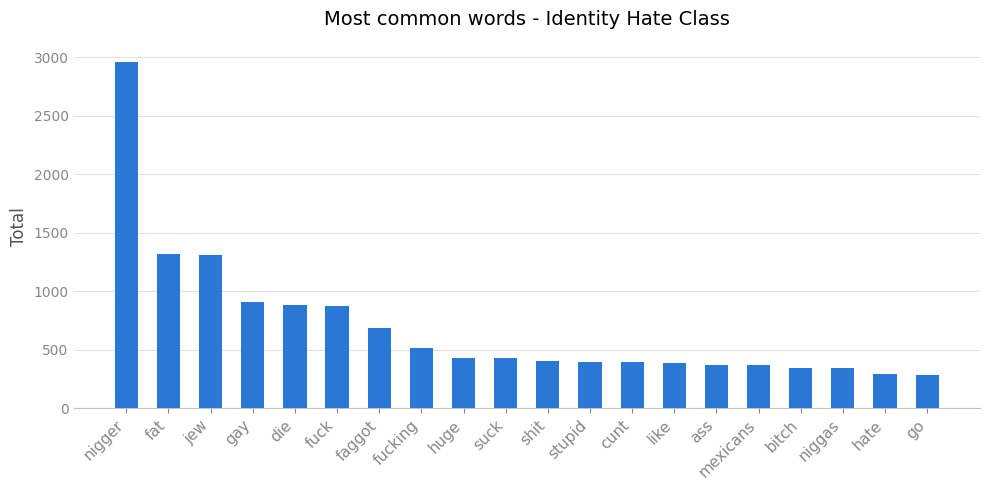

In [179]:
# Plot top 20 most common words for Identity Hate class
title = 'Most common words - Identity Hate Class'
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(hwords, hcounts, color='#2a78d6', width=0.55, zorder=3)

for bar in bars:
    bar.set_linewidth(0)

ax.set_title(title, fontsize=14, fontweight='500', pad=14)

ax.set_ylabel('Total', fontsize=12, color='#52514e')

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')

ax.tick_params(axis='x', colors='#898781', rotation=45)
ax.tick_params(axis='y', colors='#898781', length=0)
plt.setp(ax.get_xticklabels(), ha='right', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================
# STEP 2: MACHINE LEARNING MODELS - TF-IDF
# Trains and evaluates LR, SVM and MLP using
# TF-IDF feature extraction across all 6 classes
# ==============================================

## Step 2. Feature Extraction & Models - TF-IDF

###  2.1 — TF-IDF

In [180]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

In [105]:
#You have 6 labels — toxic, severe_toxic, obscene, threat, insult, identity_hate.
#This is a multi-label problem — one comment can belong to multiple classes at the same time.
#For simplicity, the first model (Logistic Regression), doing one label at a time — starting with toxic.

In [181]:
X = toxic_df['comment_text']
y = toxic_df['toxic'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [182]:
# Initialise TF-IDF vectoriser with 10,000 maximum features
# fit_transform learns vocabulary from training data and converts to numerical features
# transform applies the same vocabulary to test data without refitting
vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

### 2.2 Logistic Regression

In [183]:
# Train and evaluate Logistic Regression model for all 6 toxicity classes using TF-IDF
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

X = toxic_df['comment_text']

for class_name in classes:
    try:
            print(f'\n--- {class_name} ---') 
            y = toxic_df[class_name]

            #train_test_split
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

            #TF-IDF
            vectorizer = TfidfVectorizer(max_features=10000)
            X_train_tfidf = vectorizer.fit_transform(X_train)
            X_test_tfidf = vectorizer.transform(X_test)

            lr_model = LogisticRegression()
    
            # train the model
            lr_model.fit(X_train_tfidf, y_train)

            #predict the model
            y_pred = lr_model.predict(X_test_tfidf)
    
            # evaluate the model
            print('Accuracy:', accuracy_score(y_test, y_pred))
            print('F1:', f1_score(y_test, y_pred))
            print('Recall:', recall_score(y_test, y_pred))
            print('Precision:', precision_score(y_test, y_pred))
    
            y_pred_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]
            print('AUC:', roc_auc_score(y_test, y_pred_proba))
            
    except Exception as e:
          print(f'Error for {class_name}: {e}')


--- toxic ---
Accuracy: 0.9580448065173116
F1: 0.7395448356350904
Recall: 0.6220549738219895
Precision: 0.9117505995203837
AUC: 0.9705580722048291

--- severe_toxic ---
Accuracy: 0.9906313645621181
F1: 0.3542116630669546
Recall: 0.2554517133956386
Precision: 0.5774647887323944
AUC: 0.978836038310835

--- obscene ---
Accuracy: 0.9765627447908507
F1: 0.7411764705882353
Recall: 0.6244897959183674
Precision: 0.9114893617021277
AUC: 0.9822944413337709

--- threat ---
Accuracy: 0.9975560081466395
F1: 0.1875
Recall: 0.12162162162162163
Precision: 0.4090909090909091
AUC: 0.9752787711237508

--- insult ---
Accuracy: 0.970797430675231
F1: 0.6448170731707317
Recall: 0.5241635687732342
Precision: 0.8376237623762376
AUC: 0.9761766464003645

--- identity_hate ---
Accuracy: 0.9916340278865737
F1: 0.2644628099173554
Recall: 0.16326530612244897
Precision: 0.6956521739130435
AUC: 0.9658826466610174


### 2.3 SVM

In [184]:
# Train and evaluate SVM model for all 6 toxicity classes using TF-IDF
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

X = toxic_df['comment_text']

for class_name in classes:
    try:
        #print class name
        print(f'\n--- {class_name} ---') 
        y = toxic_df[class_name]
        
        #train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        #TF-IDF
        vectorizer = TfidfVectorizer(max_features=10000)
        X_train_tfidf = vectorizer.fit_transform(X_train)
        X_test_tfidf = vectorizer.transform(X_test)
        
        #create SVM model
        svm_model = LinearSVC(C=1, max_iter=1000)
        
        #train
        svm_model.fit(X_train_tfidf, y_train)
        
        #predict
        y_pred = svm_model.predict(X_test_tfidf) 
        
        print('Accuracy:', accuracy_score(y_test, y_pred))
        print('F1:', f1_score(y_test, y_pred))
        print('Recall:', recall_score(y_test, y_pred))
        print('Precision:', precision_score(y_test, y_pred))
        
        y_pred_proba = svm_model.decision_function(X_test_tfidf)
        print('AUC:', roc_auc_score(y_test, y_pred_proba))
        
    except Exception as e:
          print(f'Error for {class_name}: {e}')



--- toxic ---
Accuracy: 0.9617107942973523
F1: 0.7774134790528233
Recall: 0.6982984293193717
Precision: 0.876746096959737
AUC: 0.9669632559933485

--- severe_toxic ---
Accuracy: 0.9902553658154473
F1: 0.3480083857442348
Recall: 0.2585669781931464
Precision: 0.532051282051282
AUC: 0.9604442028012338

--- obscene ---
Accuracy: 0.9790067366442112
F1: 0.7804718217562254
Recall: 0.6944606413994169
Precision: 0.8908002991772626
AUC: 0.9764230301392082

--- threat ---
Accuracy: 0.9979946733510888
F1: 0.41818181818181815
Recall: 0.3108108108108108
Precision: 0.6388888888888888
AUC: 0.9705822936092086

--- insult ---
Accuracy: 0.9717060943130189
F1: 0.6780748663101605
Recall: 0.5892193308550185
Precision: 0.7984886649874056
AUC: 0.9680862586194762

--- identity_hate ---
Accuracy: 0.9922606924643584
F1: 0.3931203931203931
Recall: 0.272108843537415
Precision: 0.7079646017699115
AUC: 0.9521710363409144


### 2.4 Multi-Layer Perceptron

In [188]:
import warnings
warnings.filterwarnings('ignore')

# Train and evaluate MLP model for all 6 toxicity classes using TF-IDF
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Define X 
X = toxic_df['comment_text']
for class_name  in classes:
    try:
        # print class name
        print(f'\n--- {class_name} ---') 
        
        y = toxic_df[class_name]
        
        # train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # TF-IDF
        vectorizer = TfidfVectorizer(max_features=10000)
        X_train_tfidf = vectorizer.fit_transform(X_train)
        X_test_tfidf = vectorizer.transform(X_test)
        
        # create MLP model
        clf = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', max_iter=50, random_state=42)
        
        # fit
        clf.fit(X_train_tfidf, y_train)
        
        # predict
        y_pred = clf.predict(X_test_tfidf)
        
        # evaluate the model
        print('Accuracy:', accuracy_score(y_test, y_pred))
        print('F1:', f1_score(y_test, y_pred))
        print('Recall:', recall_score(y_test, y_pred))
        print('Precision:', precision_score(y_test, y_pred))
        
        y_pred_proba = clf.predict_proba(X_test_tfidf)[:, 1]
        print('AUC:', roc_auc_score(y_test, y_pred_proba))
    except Exception as e:
          print(f'Error for {class_name}: {e}')



--- toxic ---
Accuracy: 0.9518408271972427
F1: 0.7381155222354745
Recall: 0.7087696335078534
Precision: 0.7699964450764308
AUC: 0.9431944701708198

--- severe_toxic ---
Accuracy: 0.9879993733354222
F1: 0.37520391517128876
Recall: 0.3582554517133956
Precision: 0.3938356164383562
AUC: 0.9479809743440778

--- obscene ---
Accuracy: 0.9744007519974933
F1: 0.7533957138545125
Recall: 0.7276967930029155
Precision: 0.7809762202753442
AUC: 0.9630267603730234

--- threat ---
Accuracy: 0.9971173429421902
F1: 0.43902439024390244
Recall: 0.4864864864864865
Precision: 0.4
AUC: 0.9585418935470755

--- insult ---
Accuracy: 0.9688234372552091
F1: 0.6751550767221678
Recall: 0.6406443618339529
Precision: 0.7135955831608005
AUC: 0.9455310466767817

--- identity_hate ---
Accuracy: 0.9911640294532351
F1: 0.34418604651162793
Recall: 0.25170068027210885
Precision: 0.5441176470588235
AUC: 0.914716378313129


In [ ]:
# ==============================================
# STEP 3: MACHINE LEARNING MODELS - WORD2VEC
# Trains and evaluates LR, SVM and MLP using
# Word2Vec feature extraction across all 6 classes
# ==============================================

## 3. Feature Extraction & Models - Word Embeddings

In [189]:
# Train Word2Vec model on all comments with 100-dimensional vectors
from gensim.models import Word2Vec
sentences = [comment.lower().split() for comment in toxic_df['comment_text']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


### 3.1 Word Embeddings Vectorisation

In [190]:
import numpy as np
def getCommentVector(comment):
    """
    Converts a single commnet into averaged Word2Vec vector
    @param comment: Raw text for a single comment
    @return: a 100 vector if no words were recognized
    """
    
    # split comment into words
    words = comment.lower().split()
          
    # get vector for each word
    vectors = [ w2v_model.wv[word] for word in words if word in w2v_model.wv]
       
    # average all vectors
    if len (vectors) == 0:
        return np.zeros(100)
        
     # return the average vector
    return np.mean (vectors, axis=0)


### 3.2 Logistic Regression

In [191]:
# Convert all comments to Word2Vec vectors by averaging word vectors
X_w2v = np.array([getCommentVector(comment) for comment in toxic_df['comment_text']])

In [192]:
# Train and evaluate LR model for all 6 toxicity classes using Word2Vec
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

X = toxic_df['comment_text']

for class_name in classes:
        try:
            print(f'\n--- {class_name} ---') 
            y = toxic_df[class_name]

            # train_test_split         
            X_train, X_test, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, random_state=42)

            # create Logistic model
            lr_model = LogisticRegression()
    
            # train the model
            lr_model.fit(X_train, y_train)

            # predict the model
            y_pred = lr_model.predict(X_test)
    
            # evaluate the model
            print('Accuracy:', accuracy_score(y_test, y_pred))
            print('F1:', f1_score(y_test, y_pred))
            print('Recall:', recall_score(y_test, y_pred))
            print('Precision:', precision_score(y_test, y_pred))
    
            y_pred_proba = lr_model.predict_proba(X_test)[:, 1]
            print('AUC:', roc_auc_score(y_test, y_pred_proba))
            
        except Exception as e:
          print(f'Error for {class_name}: {e}')


--- toxic ---
Accuracy: 0.9348895503681655
F1: 0.5781567194478279
Recall: 0.46596858638743455
Precision: 0.7614973262032085
AUC: 0.9271116480943905

--- severe_toxic ---
Accuracy: 0.989691367695441
F1: 0.28322440087145967
Recall: 0.20249221183800623
Precision: 0.47101449275362317
AUC: 0.9702382466642094

--- obscene ---
Accuracy: 0.9636221212595958
F1: 0.5666293393057111
Recall: 0.4425655976676385
Precision: 0.7873443983402489
AUC: 0.9395547081651962

--- threat ---
Accuracy: 0.9973680087733041
F1: 0.10638297872340426
Recall: 0.06756756756756757
Precision: 0.25
AUC: 0.9449766024936402

--- insult ---
Accuracy: 0.9611154629484568
F1: 0.4928483857785043
Recall: 0.3736059479553903
Precision: 0.723889555822329
AUC: 0.9441770358837089

--- identity_hate ---
Accuracy: 0.9903806987310042
F1: 0.08902077151335312
Recall: 0.05102040816326531
Precision: 0.3488372093023256
AUC: 0.9231214638855131


### 3.3 SVM

In [193]:
# Train and evaluate SVM model for all 6 toxicity classes using Word2Vec
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
 
X = toxic_df['comment_text']

for class_name in classes:
    try:
        # print class name
        print(f'\n--- {class_name} ---') 
        
        # define y
        y = toxic_df[class_name]
        
        # train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, random_state=42)
        
        # create SVM model
        svm_model = LinearSVC(C=1, max_iter=300)
        
        # train
        svm_model.fit(X_train, y_train)
        
        # predict
        y_pred = svm_model.predict(X_test) 
        
        # evaluate the model
        print('Accuracy:', accuracy_score(y_test, y_pred))
        print('F1:', f1_score(y_test, y_pred))
        print('Recall:', recall_score(y_test, y_pred))
        print('Precision:', precision_score(y_test, y_pred))
        
        y_pred_proba = svm_model.decision_function(X_test)
        print('AUC:', roc_auc_score(y_test, y_pred_proba))
        
    except Exception as e:
          print(f'Error for {class_name}: {e}')



--- toxic ---
Accuracy: 0.9345448848503838
F1: 0.5533461620697028
Recall: 0.42342931937172773
Precision: 0.7982726711906231
AUC: 0.9270355480401278

--- severe_toxic ---
Accuracy: 0.990224032586558
F1: 0.1746031746031746
Recall: 0.102803738317757
Precision: 0.5789473684210527
AUC: 0.9730900441090888

--- obscene ---
Accuracy: 0.9626821243929187
F1: 0.5256869772998806
Recall: 0.3848396501457726
Precision: 0.8291457286432161
AUC: 0.9389058366960786

--- threat ---
Accuracy: 0.9976813410621964
F1: 0.02631578947368421
Recall: 0.013513513513513514
Precision: 0.5
AUC: 0.9510621610587064

--- insult ---
Accuracy: 0.9602694657684474
F1: 0.4394341290893015
Recall: 0.30793060718711274
Precision: 0.7669753086419753
AUC: 0.9461507684955413

--- identity_hate ---
Accuracy: 0.9907880307065643
F1: 0.013422818791946308
Recall: 0.006802721088435374
Precision: 0.5
AUC: 0.9295755081388047


### 3.4 MLP

In [194]:
# Train and evaluate MLPmodel for all 6 toxicity classes using Word2Vec
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Define X 
X = toxic_df['comment_text']
for class_name  in classes:
    try:
        # print class name
        print(f'\n--- {class_name} ---') 
        
        # define y
        y = toxic_df[class_name]
        
        # train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, random_state=42)
     
        # create MLP model
        clf = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', max_iter=50, random_state=42)
        
        # Train
        clf.fit(X_train, y_train)
        
        # predict
        y_pred = clf.predict(X_test)
        
        # evaluate the model
        print('Accuracy:', accuracy_score(y_test, y_pred))
        print('F1:', f1_score(y_test, y_pred))
        print('Recall:', recall_score(y_test, y_pred))
        print('Precision:', precision_score(y_test, y_pred))
        
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
        print('AUC:', roc_auc_score(y_test, y_pred_proba))
    except Exception as e:
          print(f'Error for {class_name}: {e}')


--- toxic ---
Accuracy: 0.9343882187059377
F1: 0.6449643947100712
Recall: 0.6223821989528796
Precision: 0.669247009148487
AUC: 0.9248478089624785

--- severe_toxic ---
Accuracy: 0.9893153689487701
F1: 0.3300589390962672
Recall: 0.2616822429906542
Precision: 0.44680851063829785
AUC: 0.9633422450770945

--- obscene ---
Accuracy: 0.9597681341062196
F1: 0.6207914943886592
Recall: 0.6128279883381924
Precision: 0.6289646918013165
AUC: 0.9261400092676616

--- threat ---
Accuracy: 0.9971486761710794
F1: 0.3357664233576642
Recall: 0.3108108108108108
Precision: 0.36507936507936506
AUC: 0.928666677418287

--- insult ---
Accuracy: 0.9592981356728811
F1: 0.5882725832012679
Recall: 0.5749690210656754
Precision: 0.6022063595068138
AUC: 0.9291337324433451

--- identity_hate ---
Accuracy: 0.9879053736487545
F1: 0.2825278810408922
Recall: 0.2585034013605442
Precision: 0.3114754098360656
AUC: 0.8793093563284711


In [ ]:
# ==============================================
# STEP 4: RESULTS COMPARISON
# Compares TF-IDF vs Word2Vec performance
# across all models and metrics
# ==============================================

## 4. Results Comparison

### 4.1 TF-IDF vs Word Embeddings

TF-IDF consistently outperformed Word2Vec across all three models (LR, SVM, MLP) in every metric. For the toxic class, TF-IDF achieved an average F1 of 75.1% compared to 58.0% for Word2Vec. This is because TF-IDF directly captures which words are most important and distinctive per comment, while Word2Vec averaging loses word order and frequency information by collapsing an entire comment into a single averaged vector. Word2Vec performance could potentially be improved by using more sophisticated sentence representations such as weighted averaging or transformer-based embeddings like BERT.

### 4.2 Model Comparison Table

In [195]:
# Summary results table comparing all models and feature extraction methods

results = {
    'Model': ['LR', 'SVM', 'MLP', 'LR', 'SVM', 'MLP'],
    'Feature': ['TF-IDF', 'TF-IDF', 'TF-IDF', 'Word2Vec', 'Word2Vec', 'Word2Vec'],
    'Accuracy': [95.8, 96.2, 95.0, 93.5, 93.5, 93.1],
    'F1': [73.9, 77.7, 73.7, 58.0, 55.5, 60.6],
    'Recall': [62.2, 69.8, 72.6, 46.7, 42.4, 55.3],
    'Precision': [91.2, 87.7, 74.9, 76.5, 80.3, 67.1],
    'AUC': [97.1, 96.7, 94.4, 92.8, 92.8, 89.4]
}

results_df = pd.DataFrame(results)

### 4.3 Key Findings

In [ ]:
# Key findings from model comparison

- TF-IDF outperforms Word2Vec across all 3 models and all metrics
- SVM with TF-IDF is the best overall model (highest F1: 77.7%, AUC: 96.7%)
- MLP has the best Recall with TF-IDF (72.6%) — catches more toxic comments
- Word2Vec with simple averaging loses important word order and frequency information
- Class imbalance is a key challenge — threat and identity_hate have lowest scores across all models
- Kaggle public score: 0.96570 (AUC) using SVM + TF-IDF on full training set

# ==============================================
# STEP 5: KAGGLE SUBMISSION
# Trains final SVM model on full dataset
# and generates predictions for submission
# ==============================================

## 5. Kaggle Submission

In [ ]:
test_df = pd.read_csv('../data/jigsaw-toxic-comment-classification-challenge/test.csv')

In [ ]:
# Train final SVM model on full training data and generate Kaggle submission predictions
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
predictions = {}

X_train_full = toxic_df['comment_text']
X_test_kaggle = test_df['comment_text']

for class_name in classes:
    try:
        y_train_full = toxic_df[class_name]
        vectorizer = TfidfVectorizer(max_features=10000)
        X_train_tfidf = vectorizer.fit_transform(X_train_full)
        X_test_tfidf = vectorizer.transform(X_test_kaggle)
      
        svm_model = LinearSVC(C=1, max_iter=1000)
        svm_model.fit(X_train_tfidf, y_train_full)
        
        scores = svm_model.decision_function(X_test_tfidf)
        predictions[class_name] = scores
        
    except Exception as e:
        print(f'Error for {class_name}: {e}')

In [ ]:
submission = pd.DataFrame({'id': test_df['id']})

for class_name in classes:
    submission[class_name] = predictions[class_name]

print(submission.head())
print(submission.shape)
submission.to_csv('../data/submission.csv', index=False)